# セマンティックセグメンテーション（UNet / PyTorch）

このノートブックでは、PyTorchでUNetを実装し、簡易的なセマンティックセグメンテーションを体験します。学習は最小構成にしており、必要に応じてエポック数やデータセットを拡張してください。

In [12]:
# 必要なライブラリ
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 日本語フォント設定（利用可能なものを自動選択）
def set_japanese_font():
    candidates = [
        "IPAexGothic",
        "IPAGothic",
        "Noto Sans CJK JP",
        "Noto Sans JP",
        "TakaoGothic",
        "Yu Gothic",
        "Hiragino Sans",
    ]
    available = {f.name for f in font_manager.fontManager.ttflist}
    for name in candidates:
        if name in available:
            plt.rcParams["font.family"] = name
            break
    plt.rcParams["axes.unicode_minus"] = False

set_japanese_font()

# 再現性
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# デバイス
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## 1. データ準備（合成データで簡易セグメンテーション）

本来はPASCAL VOCなどを利用しますが、ここでは実験用に合成データ（図形マスク）を生成して動作を確認します。

In [13]:
class SyntheticShapesDataset(Dataset):
    def __init__(self, size=64, length=500, train=True):
        self.size = size
        self.length = length
        self.train = train

    def __len__(self):
        return self.length

    def _draw_circle(self, img, mask, cx, cy, r):
        yy, xx = np.ogrid[:self.size, :self.size]
        dist = (xx - cx) ** 2 + (yy - cy) ** 2
        circle = dist <= r ** 2
        img[circle] = np.array([1.0, 0.6, 0.2])
        mask[circle] = 1

    def _draw_rect(self, img, mask, x0, y0, w, h):
        x1 = min(self.size, x0 + w)
        y1 = min(self.size, y0 + h)
        img[y0:y1, x0:x1] = np.array([0.2, 0.8, 0.3])
        mask[y0:y1, x0:x1] = 1

    def __getitem__(self, idx):
        rng = np.random.RandomState(seed + idx)
        img = np.zeros((self.size, self.size, 3), dtype=np.float32)
        mask = np.zeros((self.size, self.size), dtype=np.int64)

        # 背景ノイズ
        img += rng.rand(self.size, self.size, 3) * 0.05

        # 図形をランダムに配置
        if rng.rand() > 0.5:
            cx, cy = rng.randint(10, self.size - 10, size=2)
            r = rng.randint(6, 14)
            self._draw_circle(img, mask, cx, cy, r)
        else:
            x0, y0 = rng.randint(5, self.size - 20, size=2)
            w, h = rng.randint(10, 20, size=2)
            self._draw_rect(img, mask, x0, y0, w, h)

        # テンソル化
        img = TF.to_tensor(img)
        return img, torch.from_numpy(mask)


train_dataset = SyntheticShapesDataset(size=64, length=800, train=True)
val_dataset = SyntheticShapesDataset(size=64, length=200, train=False)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("train/val:", len(train_dataset), len(val_dataset))

train/val: 800 200


## 2. UNetの実装（PyTorch）

エンコーダ・デコーダ構造で、スキップ接続を持つUNetを実装します。

In [14]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self, in_ch=3, num_classes=2, base_ch=32):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base_ch)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = DoubleConv(base_ch * 2, base_ch * 4)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base_ch * 4, base_ch * 8)

        self.up3 = nn.ConvTranspose2d(base_ch * 8, base_ch * 4, 2, stride=2)
        self.dec3 = DoubleConv(base_ch * 8, base_ch * 4)
        self.up2 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, 2, stride=2)
        self.dec2 = DoubleConv(base_ch * 4, base_ch * 2)
        self.up1 = nn.ConvTranspose2d(base_ch * 2, base_ch, 2, stride=2)
        self.dec1 = DoubleConv(base_ch * 2, base_ch)

        self.out_conv = nn.Conv2d(base_ch, num_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        b = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)


model = UNet().to(device)
print(model)

UNet(
  (enc1): DoubleConv(
    (net): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): DoubleConv(
    (net): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool

## 3. 学習ループ

損失関数にはCrossEntropyを使い、ピクセルごとに2クラス分類します。

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for imgs, masks in train_loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * imgs.size(0)

    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(device)
            masks = masks.to(device)
            logits = model(imgs)
            loss = criterion(logits, masks)
            val_loss += loss.item() * imgs.size(0)

    val_loss /= len(val_loader.dataset)
    print(f"epoch {epoch+1}/{num_epochs} train_loss={train_loss:.4f} val_loss={val_loss:.4f}")

epoch 1/5 train_loss=0.4256 val_loss=0.3409
epoch 2/5 train_loss=0.2202 val_loss=0.1739
epoch 3/5 train_loss=0.1336 val_loss=0.1134
epoch 4/5 train_loss=0.0855 val_loss=0.0750
epoch 5/5 train_loss=0.0588 val_loss=0.0493


## 4. 推論結果の可視化

入力画像・予測マスク・正解マスクを並べて可視化します。

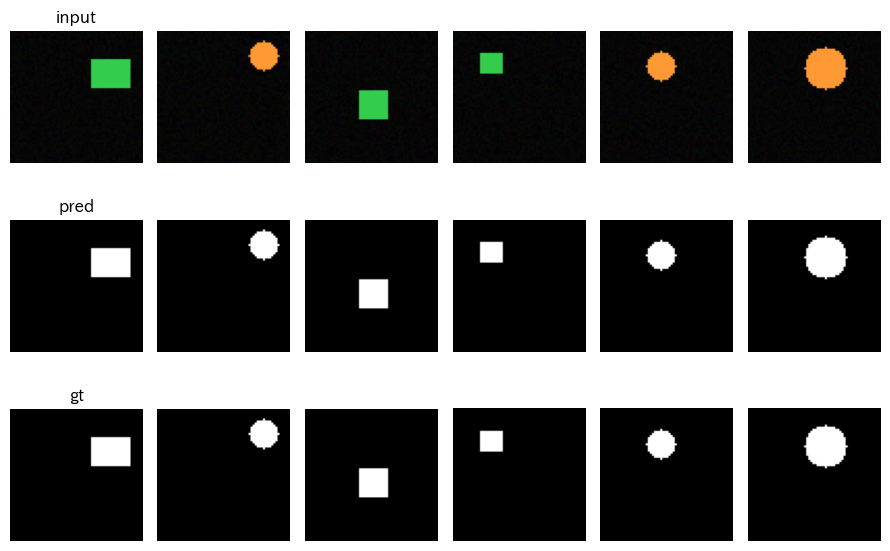

In [16]:
model.eval()

imgs, masks = next(iter(val_loader))
imgs = imgs.to(device)

with torch.no_grad():
    logits = model(imgs)
    preds = torch.argmax(logits, dim=1)

imgs = imgs.cpu()
sp = preds.cpu()
sm = masks

n_show = 6
plt.figure(figsize=(9, 6))
for i in range(n_show):
    # 入力
    ax = plt.subplot(3, n_show, i + 1)
    plt.imshow(np.transpose(imgs[i].numpy(), (1, 2, 0)))
    plt.axis("off")
    if i == 0:
        ax.set_title("input")

    # 予測
    ax = plt.subplot(3, n_show, i + 1 + n_show)
    plt.imshow(sp[i].numpy(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("pred")

    # 正解
    ax = plt.subplot(3, n_show, i + 1 + 2 * n_show)
    plt.imshow(sm[i].numpy(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("gt")

plt.tight_layout()
plt.show()

## 5. テスト画像での推論（test.jpg）

同じフォルダにあるtest.jpgを読み込み、学習済みモデルで分割結果を確認します。

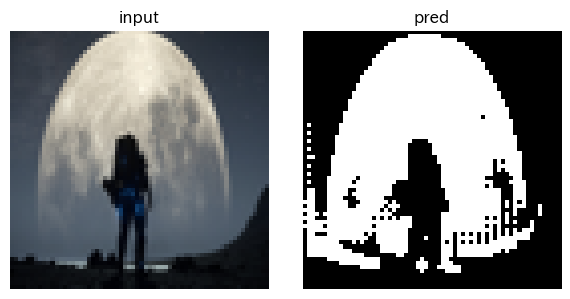

In [19]:
from PIL import Image
import os

# test.jpgの読み込み
img_path = "test.jpg"
if not os.path.exists(img_path):
    raise FileNotFoundError(f"{img_path} が見つかりません")

img = Image.open(img_path).convert("RGB")
img_resized = img.resize((64, 64))
img_tensor = TF.to_tensor(img_resized).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    logits = model(img_tensor)
    pred = torch.argmax(logits, dim=1)[0].cpu().numpy()

# 可視化
plt.figure(figsize=(6, 3))
ax = plt.subplot(1, 2, 1)
plt.imshow(img_resized)
plt.axis("off")
ax.set_title("input")

ax = plt.subplot(1, 2, 2)
plt.imshow(pred, cmap="gray")
plt.axis("off")
ax.set_title("pred")

plt.tight_layout()
plt.show()